# Raw data pre-filtering analysis
In this notebook, the raw data generated with Docker is briefly examined to determine how to filter it.

### Imports

In [34]:
import os
import pandas as pd
from tqdm import tqdm
from collections import Counter
import matplotlib.pyplot as plt
import re
import shutil
from pathlib import Path

### Paths

In [7]:
datasets_path = "./../../Repository/frame-analysis/data/raw_dataset_1"

### Listing the paths to all the csv files

In [21]:
csv_paths = []
for run_folder in os.listdir(datasets_path):
    csv_paths.append(os.path.join(datasets_path, run_folder+"/", "data.csv"))

In [22]:
len(csv_paths)

18699

### Datasets with more than a minimum number of rows (considered "good")

In [23]:
# The dataset must contain a number of rows above this threshold to be considered a good dataset
rows_threshold = 150

# Datasets (paths) that are over the threshold are saved here
good_csv_paths = []

# For each dataset, load it and check whether is above the threshold
for csv_path in tqdm(csv_paths, desc="Processing datasets", unit="dataset"):
    filepath = Path(csv_path)
    if filepath.exists():
        df = pd.read_csv(csv_path)
        rows = df.shape[0]
        if rows > rows_threshold:
            good_csv_paths.append(csv_path)

Processing datasets: 100%|█████████████████████████████████████████████████| 18699/18699 [01:21<00:00, 230.35dataset/s]


In [24]:
len(good_csv_paths)

9057

### Counting the number of good datasets per website

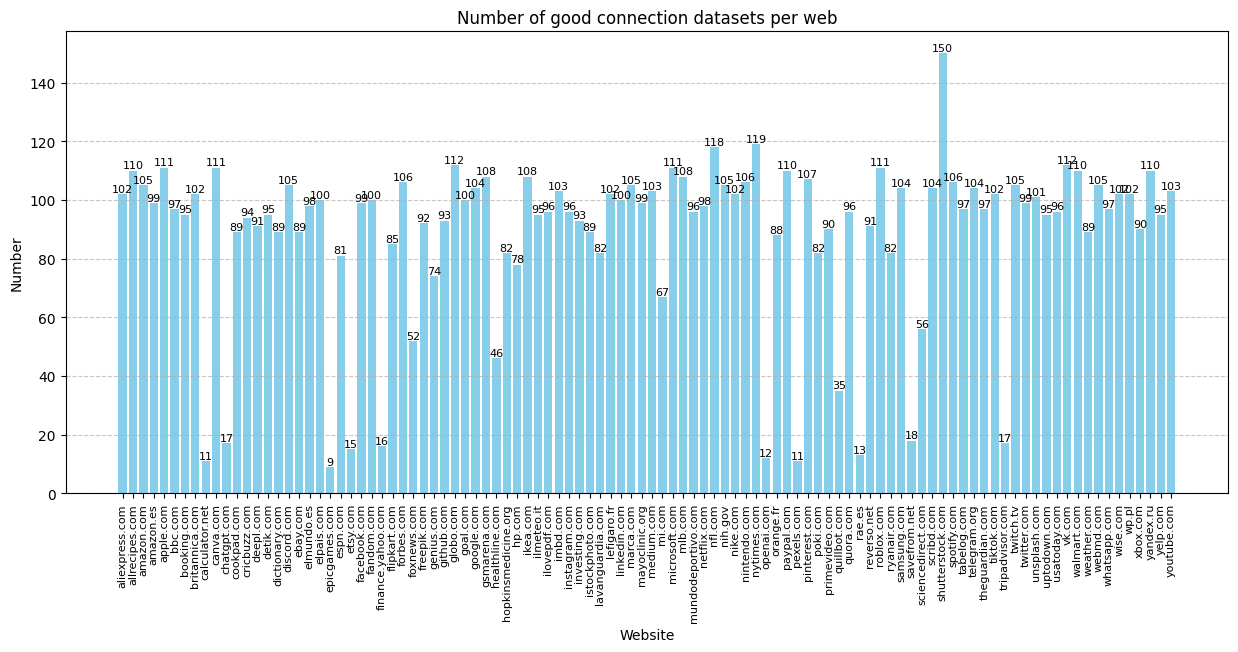

In [31]:
# Extract the domain after 'www.' and before the next '-'
good_extracted_webs = [
    re.search(r'www\.([^-\\\/]+)', path).group(1)
    for path in good_csv_paths
    if re.search(r'www\.([^-\\\/]+)', path)
]

# Count frequency of each unique element
frequency = Counter(good_extracted_webs)

# Extract elements and their counts
elements = list(frequency.keys())
counts = list(frequency.values())

# Plot the bar chart
plt.figure(figsize=(15, 6))
bars = plt.bar(elements, counts, color='skyblue')

# Add value labels on top of each bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.1, int(yval), ha='center', va='bottom', fontsize=8)

# Add grid, labels, and title
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel('Website')
plt.xticks(rotation=90, fontsize=8)
plt.ylabel('Number')
plt.title('Number of good connection datasets per web')
plt.show()

### Extracting the websites that contain at least a certain number of good datasets

In [32]:
min_num_good_datasets = 80
good_websites = [website for website, good_datasets in frequency.items() if good_datasets > min_num_good_datasets]

In [33]:
len(good_websites)

85

### Conclusion

Of the 18699 original connection datasets, we only keep those that have more than 150 frames (rows). Doing this, we end up with 9057 connection datasets. Working with these filtered datasets, we only keep those websites with more than 80 "good" connection datasets. At the end, our data consists of 85 websites with more than 80 connection datasets, each connection datasets being at least 150 frames long. This is necessary to assure both variability and homogeneity, and avoid possible biases.